# 第 12 章 · 真实图片扩散去噪代码实验

本页用真实花朵照片看扩散任务的直觉：前向过程把图像逐渐变成噪声，去噪器学习把局部 patch 修复回来。

[章节网页](../ch12.html)

## 运行内容

- 加载真实图片 patch
- 绘制前向加噪
- 展示去噪对比

## 0. 真实图片 patch

先把一张照片切成可训练的局部 patch。干净图像用于对照，后面的噪声图像和去噪图像都要和它比较。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 真实图片去噪：把一张花朵照片切成 patch，作为训练样本。
photo_clean = np.asarray(Image.fromarray(load_sample_image("flower.jpg")).resize((96, 96))).astype("float32") / 255.0
patch_size = 12
stride = 6

clean_patches = []
patch_positions = []
for row in range(0, photo_clean.shape[0] - patch_size + 1, stride):
    for col in range(0, photo_clean.shape[1] - patch_size + 1, stride):
        clean_patches.append(photo_clean[row:row + patch_size, col:col + patch_size].reshape(-1))
        patch_positions.append((row, col))
clean_patches = np.array(clean_patches)

display(pd.DataFrame({
    "图片": ["flower.jpg"],
    "图片尺寸": [f"{photo_clean.shape[0]}x{photo_clean.shape[1]}"],
    "patch 尺寸": [f"{patch_size}x{patch_size}"],
    "训练 patch 数": [len(clean_patches)],
}))

,图片,图片尺寸,patch 尺寸,训练 patch 数
0,flower.jpg,96x96,12x12,225


## 1. 加噪与去噪

第一行展示噪声增强后图像结构如何被破坏；第二行比较原图、高噪声输入、去噪输出和误差。

In [3]:
# 前向加噪：同一张真实图片在不同噪声强度下逐渐丢失结构。
rng = np.random.default_rng(11)
noise = rng.normal(size=photo_clean.shape)
noise_levels = [0.00, 0.20, 0.45, 0.70]
photo_forward = []
for level in noise_levels:
    noisy = np.sqrt(1 - level) * photo_clean + np.sqrt(level) * noise
    photo_forward.append(np.clip(noisy, 0, 1))

photo_forward_df = pd.DataFrame({
    "噪声强度": noise_levels,
    "相对原图 MSE": [mean_squared_error(photo_clean.reshape(-1), img.reshape(-1)) for img in photo_forward],
    "像素标准差": [float(img.std()) for img in photo_forward],
})
display(photo_forward_df.round(4))

,噪声强度,相对原图 MSE,像素标准差
0,0.00,0.0000,0.2364
1,0.20,0.1010,0.3289
2,0.45,0.1615,0.3740
3,0.70,0.1943,0.3937


In [4]:
# 用 patch 去噪器学习从噪声 patch 还原干净 patch。
train_rng = np.random.default_rng(12)
noisy_train = np.clip(clean_patches + train_rng.normal(0, 0.28, clean_patches.shape), 0, 1)
photo_denoiser = MLPRegressor(hidden_layer_sizes=(128,), max_iter=140, random_state=12)
photo_denoiser.fit(noisy_train, clean_patches)

noisy_photo = photo_forward[-1]
noisy_patches = []
for row, col in patch_positions:
    noisy_patches.append(noisy_photo[row:row + patch_size, col:col + patch_size].reshape(-1))
noisy_patches = np.array(noisy_patches)
predicted_patches = np.clip(photo_denoiser.predict(noisy_patches), 0, 1)

denoised_photo = np.zeros_like(photo_clean)
weight = np.zeros(photo_clean.shape[:2] + (1,), dtype=float)
for (row, col), patch in zip(patch_positions, predicted_patches):
    denoised_photo[row:row + patch_size, col:col + patch_size] += patch.reshape(patch_size, patch_size, 3)
    weight[row:row + patch_size, col:col + patch_size] += 1
denoised_photo = denoised_photo / np.maximum(weight, 1)

photo_denoise_summary = pd.DataFrame(
    [
        {"图像": "noisy", "相对原图 MSE": mean_squared_error(photo_clean.reshape(-1), noisy_photo.reshape(-1))},
        {"图像": "denoised", "相对原图 MSE": mean_squared_error(photo_clean.reshape(-1), denoised_photo.reshape(-1))},
    ]
)
display(photo_denoise_summary.round(4))

,图像,相对原图 MSE
0,noisy,0.1943
1,denoised,0.0422


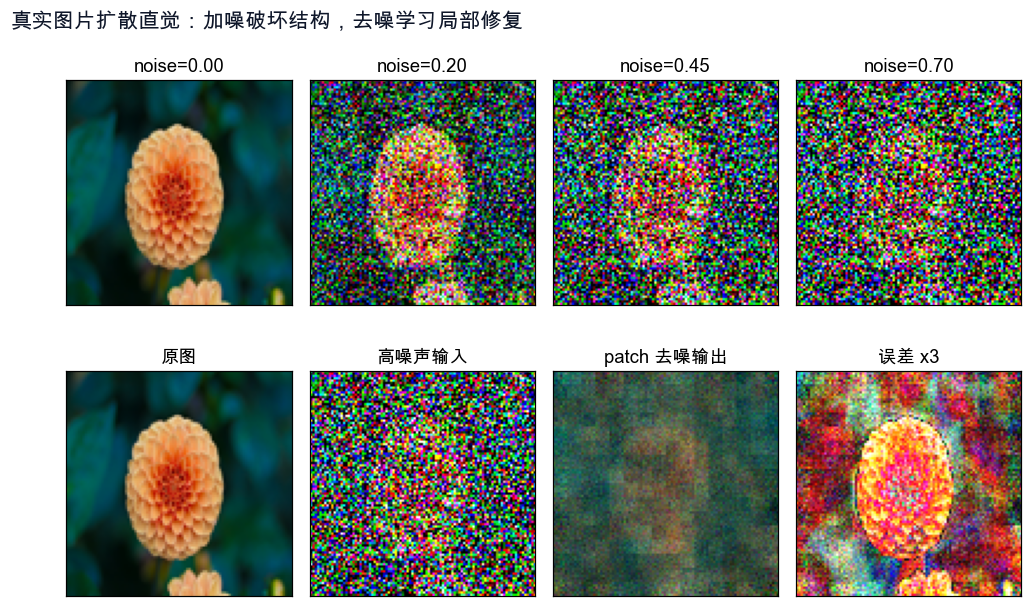

In [5]:
# 绘制真实图片的前向加噪与 patch 去噪结果。
fig = plt.figure(figsize=(11.2, 6.2))
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.05], hspace=0.24, wspace=0.08)

for idx, (img, level) in enumerate(zip(photo_forward, noise_levels)):
    ax = fig.add_subplot(gs[0, idx])
    ax.imshow(img)
    ax.set_title(f"noise={level:.2f}", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

for idx, (img, title) in enumerate([
    (photo_clean, "原图"),
    (noisy_photo, "高噪声输入"),
    (denoised_photo, "patch 去噪输出"),
    (np.abs(photo_clean - denoised_photo) * 3, "误差 x3"),
]):
    ax = fig.add_subplot(gs[1, idx])
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("真实图片扩散直觉：加噪破坏结构，去噪学习局部修复", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()